In [1]:
import pandas as pd
import numpy as np
import os
from sqlalchemy import create_engine, inspect

In [2]:
# Set up MySQL connection details
username = 'root'
password = 'Raisha789'
host = 'localhost'
port = 3306
database = 'superstor_db'

In [3]:
# Create SQLAlchemy engine for MySQL connection
engine = create_engine(f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}')

In [4]:
conn = engine.connect()
conn

In [5]:
tables_df = pd.read_sql("show tables",conn)
tables_df

,Tables_in_superstor_db
0,cleaned_raw_data
1,customer_dim
2,product_dim
3,sales_fact
4,superstore_data


In [6]:
df_customer = pd.read_sql("Select * from customer_dim;",conn)
df_sales = pd.read_sql("Select * from sales_fact;",conn)
df_product = pd.read_sql("Select * from product_dim;",conn)

In [7]:
df_customer.head()

,customer_id,customer_name,segment,country,city,state,postal_code,region
0,cg-12520,claire gute,consumer,united states,henderson,kentucky,42420,south
1,dv-13045,darrin van huff,corporate,united states,los angeles,california,90036,west
2,so-20335,sean o'donnell,consumer,united states,fort lauderdale,florida,33311,south
3,bh-11710,brosina hoffman,consumer,united states,los angeles,california,90032,west
4,aa-10480,andrew allen,consumer,united states,concord,north carolina,28027,south


In [8]:
df_sales.head()

,order_id,order_date,ship_date,ship_mode,customer_id,product_id,sales,quantity,discount,profit
0,ca-2016-152156,2016-11-08,2016-11-11,second class,cg-12520,fur-bo-10001798,261.96,2,0.00,41.9136
1,ca-2016-152156,2016-11-08,2016-11-11,second class,cg-12520,fur-ch-10000454,731.94,3,0.00,219.5820
2,ca-2016-138688,2016-06-12,2016-06-16,second class,dv-13045,off-la-10000240,14.62,2,0.00,6.8714
3,us-2015-108966,2015-10-11,2015-10-18,standard class,so-20335,fur-ta-10000577,957.58,5,0.45,-383.0310
4,us-2015-108966,2015-10-11,2015-10-18,standard class,so-20335,off-st-10000760,22.37,2,0.20,2.5164


In [9]:
df_product.head()

,product_id,category,sub_category,product_name
0,fur-bo-10001798,furniture,bookcases,bush somerset collection bookcase
1,fur-ch-10000454,furniture,chairs,"hon deluxe fabric upholstered stacking chairs,..."
2,off-la-10000240,office supplies,labels,self-adhesive address labels for typewriters b...
3,fur-ta-10000577,furniture,tables,bretford cr4500 series slim rectangular table
4,off-st-10000760,office supplies,storage,eldon fold 'n roll cart system


- Cleaning and EDA is already done for the data now will directly go to  Classification for predictive analysis 

## Classification predictive analysis 

In [10]:
df = pd.read_sql("""
SELECT
    c.customer_id,
    c.segment,
    s.order_id,
    s.order_date,
    s.sales,
    s.profit,
    s.quantity,
    s.discount
FROM sales_fact s
JOIN customer_dim c
    ON s.customer_id = c.customer_id
""", conn)

In [11]:
df.head()

,customer_id,segment,order_id,order_date,sales,profit,quantity,discount
0,cg-12520,consumer,ca-2016-152156,2016-11-08,261.96,41.9136,2,0.0
1,cg-12520,consumer,ca-2016-152156,2016-11-08,261.96,41.9136,2,0.0
2,cg-12520,consumer,ca-2016-152156,2016-11-08,261.96,41.9136,2,0.0
3,cg-12520,consumer,ca-2016-152156,2016-11-08,731.94,219.5820,3,0.0
4,cg-12520,consumer,ca-2016-152156,2016-11-08,731.94,219.5820,3,0.0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68801 entries, 0 to 68800
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  68801 non-null  object 
 1   segment      68801 non-null  object 
 2   order_id     68801 non-null  object 
 3   order_date   68801 non-null  object 
 4   sales        68801 non-null  float64
 5   profit       68801 non-null  float64
 6   quantity     68801 non-null  int64  
 7   discount     68801 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 4.2+ MB


In [13]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68801 entries, 0 to 68800
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  68801 non-null  object        
 1   segment      68801 non-null  object        
 2   order_id     68801 non-null  object        
 3   order_date   68801 non-null  datetime64[ns]
 4   sales        68801 non-null  float64       
 5   profit       68801 non-null  float64       
 6   quantity     68801 non-null  int64         
 7   discount     68801 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(3)
memory usage: 4.2+ MB


In [15]:
df['order_date'] = df['order_date'].dt.to_period('M')

In [16]:
df.head()

,customer_id,segment,order_id,order_date,sales,profit,quantity,discount
0,cg-12520,consumer,ca-2016-152156,2016-11,261.96,41.9136,2,0.0
1,cg-12520,consumer,ca-2016-152156,2016-11,261.96,41.9136,2,0.0
2,cg-12520,consumer,ca-2016-152156,2016-11,261.96,41.9136,2,0.0
3,cg-12520,consumer,ca-2016-152156,2016-11,731.94,219.5820,3,0.0
4,cg-12520,consumer,ca-2016-152156,2016-11,731.94,219.5820,3,0.0


###  Goal :- Customer Value Classification predictive analysis (High / Low)

#### Data collecting 

In [17]:
customer_df  = df.groupby('customer_id').agg({
    'sales': 'sum',
    'profit': 'sum',
    'quantity': 'sum',
    'discount': 'mean',
    'order_id': 'count'
}).reset_index()

In [19]:
threshold =  customer_df['profit'].median()

In [20]:
customer_df['customer_value'] = customer_df['profit'].apply( lambda x : 'High' if x >= threshold else 'Low')

#### Data preprocessing

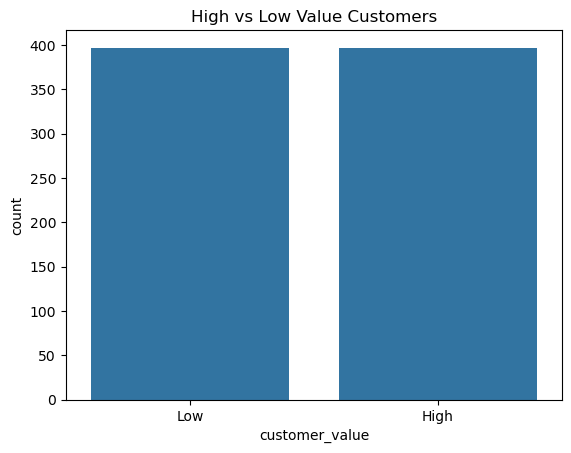

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=customer_df, x='customer_value')
plt.title("High vs Low Value Customers")
plt.show()

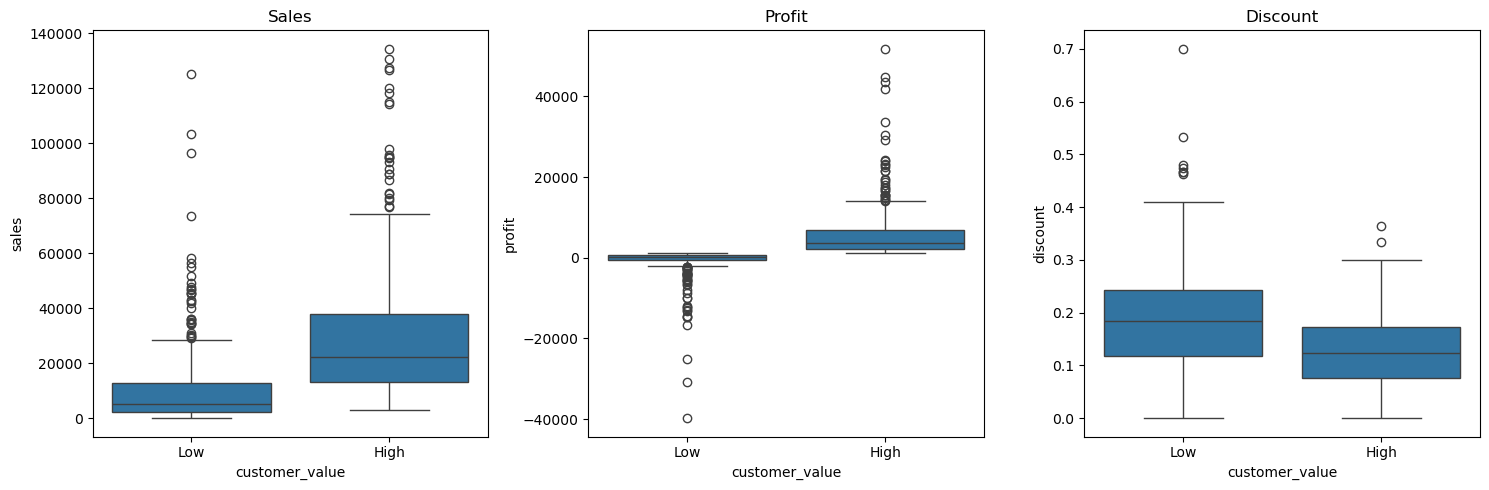

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=customer_df, x='customer_value', y='sales', ax=axes[0])
axes[0].set_title("Sales")

sns.boxplot(data=customer_df, x='customer_value', y='profit', ax=axes[1])
axes[1].set_title("Profit")

sns.boxplot(data=customer_df, x='customer_value', y='discount', ax=axes[2])
axes[2].set_title("Discount")

plt.tight_layout()
plt.show()

- Sales are high on high value customer 
- Profit is high and in low customer there are losses
- Discount is high in low customer 

#### Featuring 

In [23]:
X = customer_df[['sales','quantity','discount','profit','order_id']]
y = customer_df['customer_value']

In [24]:
X = X.fillna(0)   # Convert categories to numbers

#### Split and train

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Model the train

In [33]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

#### Prediction

In [34]:
y_predict = model.predict(X_test_scaled)

#### Validating

In [35]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_predict)

0.9559748427672956

## So 95% the prediction value is accurate 

In [36]:
result = X_test.copy()

In [37]:
result['predicted_value'] = y_predict

In [38]:
result['actual_value'] = y_test.values

In [39]:
result = result.merge(
    customer_df['customer_id'],
    left_index=True,
    right_index=True
)

In [40]:
result.head(10)

,sales,quantity,discount,profit,order_id,predicted_value,actual_value,customer_id
137,11416.48,204,0.250000,3400.6368,48,High,High,cc-12685
198,8086.47,231,0.160000,1243.7145,70,Low,Low,db-13660
739,6937.85,145,0.271429,-682.0455,35,Low,Low,tb-21595
583,2753.32,72,0.120000,872.6372,20,Low,Low,pb-19105
655,1231.86,14,0.275000,-147.6700,8,Low,Low,rr-19315
63,9732.18,240,0.125000,929.7018,72,Low,Low,az-10750
275,93127.02,2108,0.197419,2464.2707,527,High,High,ep-13915
521,14503.37,371,0.107692,2866.5798,91,High,High,ml-17755
467,2269.80,117,0.111111,332.3439,27,Low,Low,lp-17080
78,4100.60,245,0.172727,1547.3129,77,Low,High,bf-10975


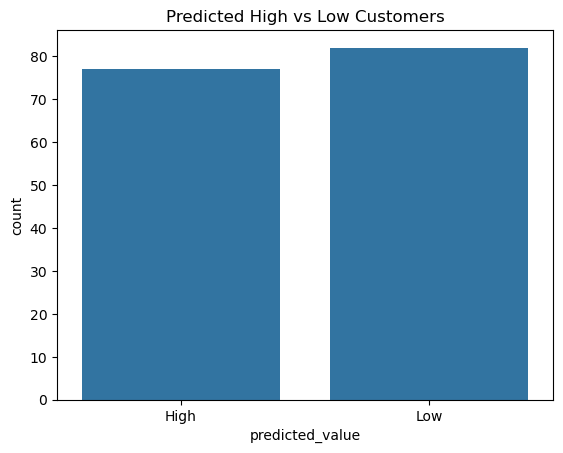

In [41]:
sns.countplot(data=result, x='predicted_value')
plt.title("Predicted High vs Low Customers")
plt.show()

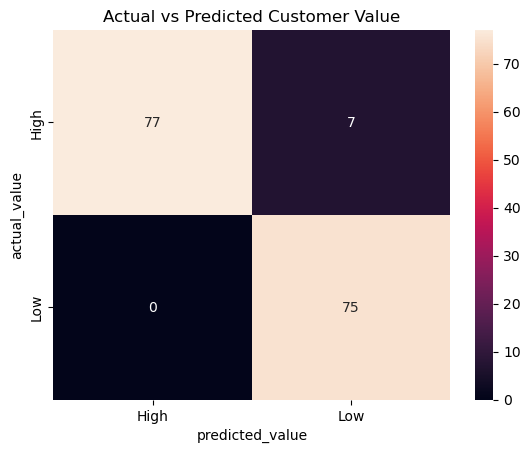

In [42]:
pd.crosstab(result['actual_value'], result['predicted_value'])

sns.heatmap(
    pd.crosstab(result['actual_value'], result['predicted_value']),
    annot=True,
    fmt='d'
)
plt.title("Actual vs Predicted Customer Value")
plt.show()

 1) The model shows strong performance with high accuracy (~95.6%)
 2) Identified High-value predictions without false positives
 3) misses 7 High-value customers
 4) the model is highly reliable for business decision-making.

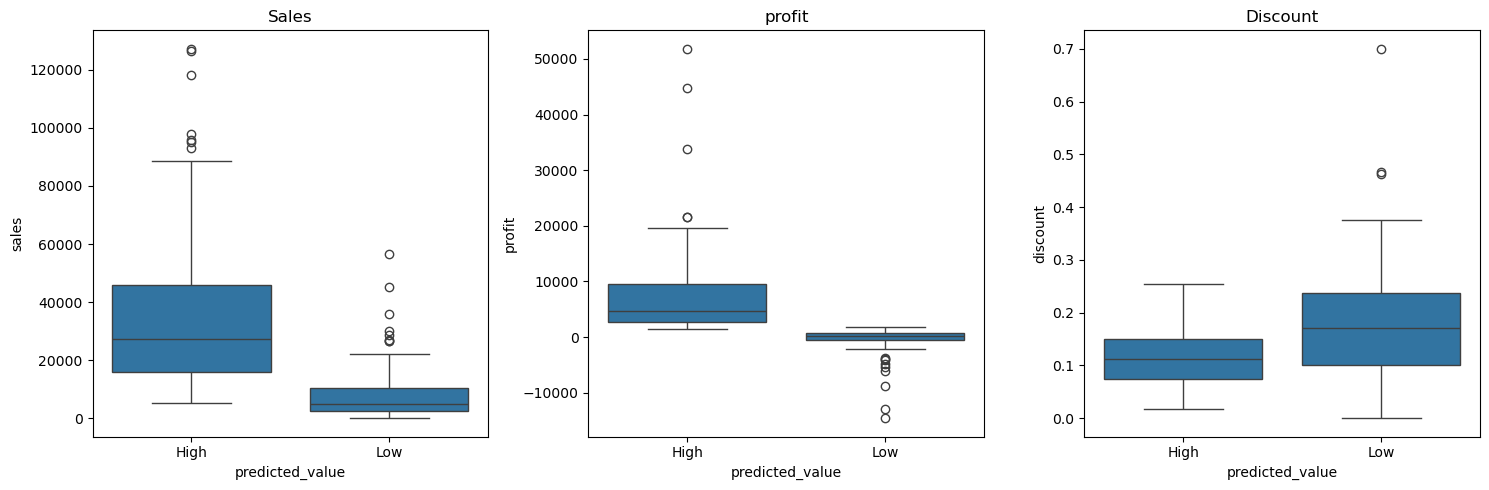

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=result, x='predicted_value', y='sales', ax=axes[0])
axes[0].set_title("Sales")

sns.boxplot(data=result, x='predicted_value', y='profit', ax=axes[1])
axes[1].set_title("profit")

sns.boxplot(data=result , x='predicted_value', y='discount', ax=axes[2])
axes[2].set_title("Discount")

plt.tight_layout()
plt.show()

- The predicted customer segments follow clear behavioral and financial patterns.
- High-value customers are associated with:
    - higher sales
    - higher profit
    - relatively controlled discount usage
- Low-value customers are associated with:
   - lower sales
   - lower or negative profit
   - higher discount dependency

## Classification predictive analysis - By behavior model prediction


In [56]:
#featuring
X_b = customer_df[['quantity','discount','order_id']]
y = customer_df['customer_value']

In [57]:
#train and split 
X_b_train, X_b_test, y_train, y_test = train_test_split(
    X_b, y,
    test_size=0.2,
    random_state=42
)

In [58]:
#train model

model = LogisticRegression(max_iter=1000)
model.fit(X_b_train, y_train)

LogisticRegression(max_iter=1000)

In [59]:
#prediction
y_pred = model.predict(X_b_test)

In [60]:
#Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7421383647798742
Confusion Matrix:
 [[54 30]
 [11 64]]

Classification Report:
               precision    recall  f1-score   support

        High       0.83      0.64      0.72        84
         Low       0.68      0.85      0.76        75

    accuracy                           0.74       159
   macro avg       0.76      0.75      0.74       159
weighted avg       0.76      0.74      0.74       159



In [65]:
result_b = X_b_test.copy()
result_b['actual_value'] = y_test.values
result_b['predicted_value'] = y_pred

result_b.head()

,quantity,discount,order_id,actual_value,predicted_value
137,204,0.250000,48,High,Low
198,231,0.160000,70,Low,Low
739,145,0.271429,35,Low,Low
583,72,0.120000,20,Low,Low
655,14,0.275000,8,Low,Low


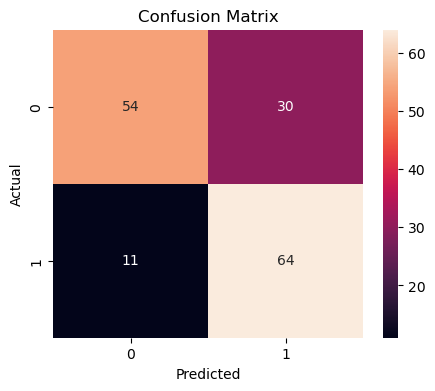

In [66]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [63]:
print("Model Accuracy:", accuracy_score(y_test, y_pred))

Model Accuracy: 0.7421383647798742


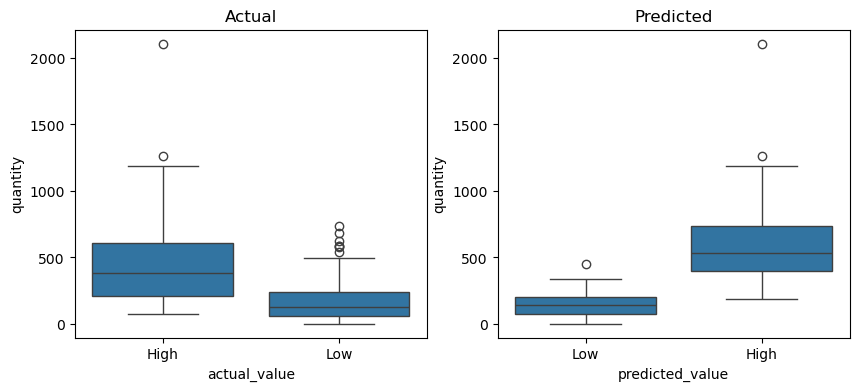

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.boxplot(data= result_b, x='actual_value', y='quantity', ax=axes[0])
axes[0].set_title("Actual")

sns.boxplot(data= result_b, x='predicted_value', y='quantity', ax=axes[1])
axes[1].set_title("Predicted")

plt.show()

### Action and Recommendations
1) Focus on High-Value Customers :- This helps improve customer retention and long-term revenue.
2) Monitor Misclassified Customers :- These customers should be monitored carefully before applying expensive marketing strategies to avoid unnecessary business costs.
3) Apply Targeted Marketing
4) Validate Predictions Before Major Decisions
5) Improve Model Accuracy by recency of purchase, average order of gap , customer tenure, product category .

Buisness Insights 

- Businesses should focus retention strategies on predicted High-value customers through loyalty programs and personalized engagement.
- Discount-heavy strategies should be monitored carefully for Low-value customers, as higher discounts do not necessarily improve profitability.

### Final Conclusion
The model successfully captures meaningful customer purchasing patterns, separating customers based on revenue contribution, profitability, and discount behavior. This supports targeted marketing and customer segmentation decisions.